### Restricted Kohn–Sham (RKS) tutorial

This tutorial shows how to use custom restricted Kohn–Sham algorithm `RKS.py`. 

#### Necessary imports

In [7]:
import sys
import psi4
import numpy as np

%load_ext autoreload
%autoreload 2
sys.path.append('/Users/ivanbosko/Documents/CODES/GIT/DFT-Tools/SCF') 

import RKS

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


#### Choice of a density functional

Any KS calculation requires a choice of the approximation to the exchange-correlation (XC) energy functional. 

XC approximations can be used together or split into exchange-only (X) and correlation-only (C) functionals.

The list of approximate functionals available in Psi4 is given in the `LibXC` website (https://libxc.gitlab.io/functionals/).

All functionals are given a `LibXC` name and an alias. The latter is how the functional is usually called in the literature or how you are used to be calling it. For example, the alias "EXX" stands for the exact exchange functional, and the alias "LDAx" stands for the local density approximation to the exchange energy. The first one is not given in LibXC (custom functional), the latter is listed as `LDA_X` in `LibXC`. 

To specify the functional, use a dictionary as follows:

In [8]:
EXX = {
    "name": "EXX", 
    "x_hf": {"alpha": 1.00}, # fraction of the exact exchange (1.0 for exact exchange)
    "x_functionals": {"LDA_X": {"alpha": 0.00}}, # type and fraction of an approximate exchange functional (0.0 for exact exchange)
    "c_functionals": {"GGA_K_VW": {"alpha": 0.00}} # type and fraction of an approximate correlation functional (0.0 for exact exchange)
    }
LDAx = {
    "name": "LDAx",
    "x_hf": {"alpha": 0.00}, 
    "x_functionals": {"LDA_X": {"alpha": 1.00}},
    "c_functionals": {"LDA_C_VWN_RPA": {"alpha": 0.00}}
    }

The `"x_hf"` entry can be skipped if desired.

However, both `"x_functionals"` and `"x_functionals"` must be specified at all times. Skipping any of those will trigger an error. 

If you wish not to use an exchange or a correlation functional simply use `"alpha": 0.00`. 

To avoid listing each functional inside this notebook, use `custom_xc_functionals.py` script containing all of your custom functionals.

In [9]:
# Load XC functional dictionaries from the SCF module
import custom_functionals

EXX = custom_functionals.EXX
LDAx = custom_functionals.LDAx

#### Molecule specification

To store the molecular specification we will use the syntax used by `Psi4` program.

For example, the the specification of the Ne atom is given by (`symmetry c1` turns off the molecular symmetry):

In [10]:
ne = psi4.geometry(f"""
units bohr
0 1
Ne                  
symmetry c1
""")

The Z-matrix coordinates of the water molecule are given by (here, the symmetry is set to the $C_{\text{2V}}$ point group):

In [11]:
h2o = psi4.geometry(f"""
units bohr
0 1
O
H 1 1.81
H 1 1.81 2 104.5                      
symmetry c2v
""")

#### Output file and `Psi4` options

Set the ouput file first:

In [12]:
psi4.core.set_output_file('output.dat', False)

Choose the method: EXX or LDAx.

Choose the basis set, for example, def2-SVP.

Choose the number of the spherical and radial points for the numerical integration grid used by the KS algorithm.

In [13]:
method = LDAx

psi4.set_options({"basis": "def2-svp",
                  "DFT_SPHERICAL_POINTS": 302,
                  "DFT_RADIAL_POINTS": 350
                  })

#### Sample KS calculations

Run a KS calculation using the custom script from `RKS.py`:

In [15]:
E, D, homo, scf_iter = RKS.ks_solver(ne, method, damp=0.0, DIIS=True)
print(f"\nFinal SCF Energy: {E:.6f} Hartree")


Final SCF Energy: -127.306730 Hartree


Compare the energy produced by the custom `RKS.py` to the SCF energy by the `Psi4` program:

In [10]:
psi4.set_options({"scf_type": "PK",
                  "d_convergence": 1e-8,
                  "e_convergence": 1e-8
                  })
mol = ne
psi4_E, psi4_wfn = psi4.energy('SCF', dft_functional=method, molecule=ne, return_wfn=True)
print(f"Psi4 SCF Energy: {psi4_E:.6f} Hartree")

Psi4 SCF Energy: -127.306730 Hartree


The `"PK"` SCF algorithm and the convergence thresholds are chosen to match the ones used by `RKS.py`. The same basis set and integration grid are used by both `Psi4` and `RKS.py`

In [16]:
E, D, homo, scf_iter = RKS.ks_solver(h2o, method, damp=0.0, DIIS=True)
psi4_E, psi4_wfn = psi4.energy('SCF', dft_functional=method, molecule=h2o, return_wfn=True)

print(f"\nH2O SCF Energy: {E:.6f} Hartree\nH2O Psi4 SCF Energy: {E:.6f} Hartree")


H2O SCF Energy: -75.130560 Hartree
H2O Psi4 SCF Energy: -75.130560 Hartree


#### $\text{H}_2$ dissociation curve

A classic molecular test system is a hydrogen molecule.

We will generate its dissociation curve using three exchange functionals (EXX, LDAx, PBEx) using `RKS.py` and `Psi4` programs.

In [ ]:
PBEx = custom_functionals.PBEx
method_list = [EXX, LDAx, PBEx]
diss_curve_dict = {}

Imports for inline plotting:

In [40]:
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

Dissociation curves produced with Psi4:

In [49]:
dist = np.linspace(0.5, 10.5, 81)

for method in method_list:
    energy_list = np.array([])
    for d in dist:

        mol = psi4.geometry(f"""
            units bohr
            0 1
            H
            H 1 {d}
            symmetry c1
            """)

        energy, wfn = psi4.energy('SCF', dft_functional=method, molecule=mol, return_wfn=True)
        energy_list = np.append(energy_list, energy)

    diss_curve_dict[method['name']] = energy_list

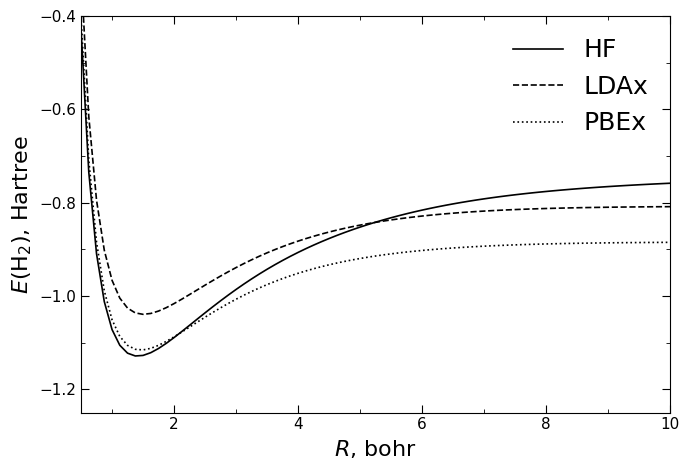

In [51]:
fig, ax = plt.subplots(figsize=(7, 4.8))
plt.plot(dist, diss_curve_dict["EXX"], color='black', linestyle='-', linewidth=1.2, label=r'HF')
plt.plot(dist, diss_curve_dict["LDAx"], color='black', linestyle='--', linewidth=1.2, label=r'LDAx')
plt.plot(dist, diss_curve_dict["PBEx"], color='black', linestyle=':', linewidth=1.2, label=r'PBEx')

ax.tick_params(axis='both', which='major', direction='in', top=True, right=True, length=6, labelsize=11)
ax.tick_params(axis='both', which='minor', direction='in', top=True, right=True, length=3)
ax.yaxis.set_major_locator(MultipleLocator(0.2))
ax.yaxis.set_minor_locator(MultipleLocator(0.1))
ax.xaxis.set_major_locator(MultipleLocator(2.0))
ax.xaxis.set_minor_locator(MultipleLocator(1.0))
ax.set_xlabel(r'$R$, bohr', fontsize=16)
ax.set_ylabel(r'$E (\text{H}_2)$, Hartree', fontsize=16)

ax.legend(frameon=False, loc='best', fontsize=18)
ax.set_xlim(0.5, 10)
ax.set_ylim(-1.25, -0.4)
plt.tight_layout()
plt.show()

Dissociation curves produced with custom `RKS.py`:

In [52]:
dist = np.linspace(0.5, 10.5, 81)

for method in method_list:
    energy_list = np.array([])
    for d in dist:

        mol = psi4.geometry(f"""
            units bohr
            0 1
            H
            H 1 {d}
            symmetry c1
            """)

        E, D, homo, scf_iter = RKS.ks_solver(mol, method, damp=0.0, DIIS=True)
        energy_list = np.append(energy_list, E)

    diss_curve_dict[method['name']] = energy_list

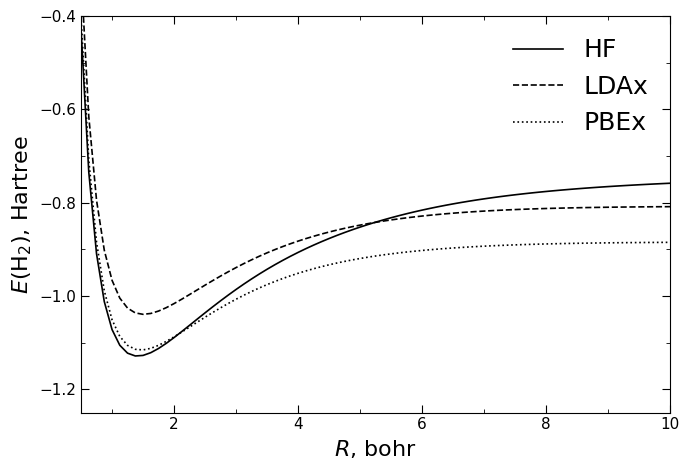

In [53]:
fig, ax = plt.subplots(figsize=(7, 4.8))
plt.plot(dist, diss_curve_dict["EXX"], color='black', linestyle='-', linewidth=1.2, label=r'HF')
plt.plot(dist, diss_curve_dict["LDAx"], color='black', linestyle='--', linewidth=1.2, label=r'LDAx')
plt.plot(dist, diss_curve_dict["PBEx"], color='black', linestyle=':', linewidth=1.2, label=r'PBEx')

ax.tick_params(axis='both', which='major', direction='in', top=True, right=True, length=6, labelsize=11)
ax.tick_params(axis='both', which='minor', direction='in', top=True, right=True, length=3)
ax.yaxis.set_major_locator(MultipleLocator(0.2))
ax.yaxis.set_minor_locator(MultipleLocator(0.1))
ax.xaxis.set_major_locator(MultipleLocator(2.0))
ax.xaxis.set_minor_locator(MultipleLocator(1.0))
ax.set_xlabel(r'$R$, bohr', fontsize=16)
ax.set_ylabel(r'$E (\text{H}_2)$, Hartree', fontsize=16)

ax.legend(frameon=False, loc='best', fontsize=18)
ax.set_xlim(0.5, 10)
ax.set_ylim(-1.25, -0.4)
plt.tight_layout()
plt.show()